## heat budget for change in OHC = change in MHT - change in F_s

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import palettable.colorbrewer as cb 

from statsmodels.tsa.stattools import ccf
from PIL import Image
import io

from process_raw_data import process_data, decimal_year_to_datetime
from stats_plots import zero_lag_corr_hf_mht, compute_n_eff_and_r_crit, parse_lat_label, plot_hovmöller, plot_lead_lag_single_region

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")
ds

<xarray.Dataset> Size: 96MB
Dimensions:   (lat: 12, time: 67, posterior_samples: 4000, number_regions: 11)
Coordinates:
  * time      (time) float64 536B 2.004e+03 2.004e+03 ... 2.02e+03 2.021e+03
Dimensions without coordinates: lat, posterior_samples, number_regions
Data variables:
    latitude  (lat) float64 96B ...
    mht       (lat, time, posterior_samples) float64 26MB ...
    htc       (number_regions, time, posterior_samples) float64 24MB ...
    ohct      (number_regions, time, posterior_samples) float64 24MB ...
    qnet      (number_regions, time, posterior_samples) float64 24MB ...
Attributes:
    creation data:                   21-Mar-2026 12:07:15
    institution:                     National Oceanography Centre, UK / Unive...
    contact:                         francisco.mcalafat@uib.eu
    title:                           Observation-based probabilistic estimate...
    comment on temporal resolution:  Estimates of heat transport are quarterl...

In [3]:

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


ds["time"] = decimal_year_to_datetime(ds.time.values)

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")

mht_detrended = process_data(mht_mean, detrended=True, restore_mean=True)
mht_detrended_anom = process_data(mht_mean, detrended=True).dropna(dim="time", how="any")

# # surface heat flux

hf = ds.qnet.dropna(dim="time", how="any")
hf_mean = hf.mean(dim="posterior_samples")
hf_detrended = process_data(hf_mean, detrended=True,)
# drop first time step, since mht starts 2004-05 not 2004-02
# hf_detrended = hf_detrended.isel(time=slice(1,None))

## heat transport convergence

htc = ds.htc.dropna(dim="time", how="any")
htc_mean = htc.mean(dim="posterior_samples")
htc_detrended = process_data(htc_mean, detrended=True,)

## ocean heat content tendency
ohct = ds.ohct.dropna(dim="time", how="any")
ohct_mean = ohct.mean(dim="posterior_samples")
ohct_detrended = process_data(ohct_mean, detrended=True,)
# drop first time step, since mht starts 2004-05 not 2004-02
ohct_detrended = ohct_detrended.isel(time=slice(1,None))

## lats and regions
region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}-{fmt(lat2)}")
    
# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)

regions = np.arange(hf_detrended.sizes["number_regions"])

region_bounds = []
print(region_labels)
for i, label in enumerate(region_labels):
    lo, hi = (parse_lat_label(b) for b in label.split("-", 1))
    region_bounds.append((lo, hi))
    
region_info = {"idx": regions, "labels": region_labels, "bounds": region_bounds}

['65°N-60°N', '60°N-55°N', '55°N-45°N', '45°N-35°N', '35°N-26°N', '26°N-16°N', '16°N-5°N', '5°N-5°S', '5°S-11°S', '11°S-25°S', '25°S-35°S']


## region of interest 16°N-5°N

In [4]:
idx_16 = [np.where((lats == 16))[0][0]]
idx_5 = [np.where((lats == 5))[0][0]]

## mht
mht_16N = mht_detrended_anom.isel(lat=idx_16)
mht_5N = mht_detrended_anom.isel(lat=idx_5)
mht_diff_16_5 = - mht_16N + mht_5N
mht_diff_16_5 = mht_diff_16_5.squeeze('lat', drop=True)

## hf
idx_16_5 = [i for i, label in enumerate(region_labels) if label == "16°N-5°N"][0]
hf_16_5 = hf_detrended.isel(number_regions=idx_16_5)

In [5]:
ohc_dt_calc = mht_diff_16_5 + hf_16_5
ohct_16_5 = ohct_detrended.isel(number_regions=idx_16_5)

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4675/97126587.py:4: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(mht_diff_16_5.time, mht_diff_16_5, label="$\Delta$ MHT", color=colors[0])


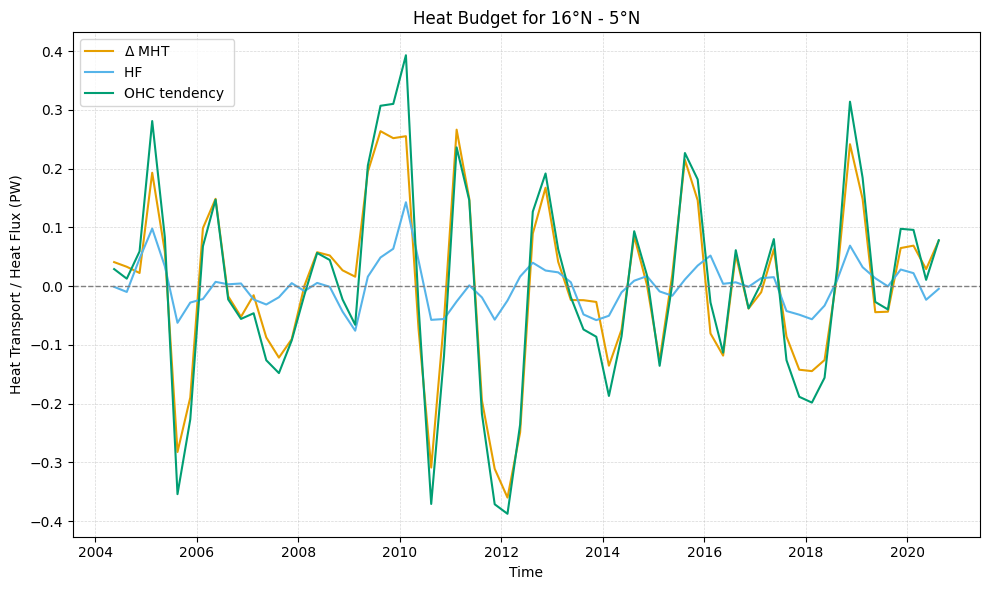

In [6]:
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]

fig = plt.figure(figsize=(10, 6))
plt.plot(mht_diff_16_5.time, mht_diff_16_5, label="$\Delta$ MHT", color=colors[0])
plt.plot(hf_16_5.time, hf_16_5, label="HF ", color=colors[1])
plt.plot(ohct_16_5.time, ohct_16_5, label="OHC tendency ", color=colors[2])
# plt.plot(ohc_dt_calc.time, ohc_dt_calc, label="MHT - HF ", color=colors[5])

plt.title("Heat Budget for 16°N - 5°N")
plt.xlabel("Time")
plt.ylabel("Heat Transport / Heat Flux (PW)")
plt.axhline(0, color="grey", linewidth=1.0, linestyle="--")
plt.legend()
plt.grid(alpha=0.5, linestyle="--", linewidth=0.5)
plt.tight_layout()
os.makedirs("heatbudget/", exist_ok=True)
plt.savefig(f"heatbudget/16_5N_components", dpi=300, bbox_inches='tight')



In [9]:
def variance_fraction(term, total):
    term_v = term.values.flatten()
    total_v = total.values.flatten()
    cov = np.cov(term_v, total_v)[0, 1]
    var_total = np.var(total_v)
    return cov / var_total

periods = {
    "pre2009": ("2004", "2008-11"),
    "2009_2014": ("2009", "2014-11"),
    "post2014": ("2015", "2020"),
    "total": ("2004", "2020")
}

for period_name, (t0, t1) in periods.items():
    period_del_mht = mht_diff_16_5.sel(time=slice(t0, t1))
    period_hf = hf_16_5.sel(time=slice(t0, t1))
    period_ohct = ohct_16_5.sel(time=slice(t0, t1))
    
        
    f_mht = variance_fraction(period_del_mht, period_ohct)
    f_fs  = variance_fraction(period_hf, period_ohct)
    print(f"Variance fractions for {period_name}:")
    print(f_mht, f_fs, f_mht + f_fs)  # sums to 1

Variance fractions for pre2009:
0.8479969582666281 0.2091811754792516 1.0571781337458797
Variance fractions for 2009_2014:
0.8779412344524377 0.167666973523977 1.0456082079764146
Variance fractions for post2014:
0.856510381359764 0.18730782419403946 1.0438182055538034
Variance fractions for total:
0.8403483321889379 0.17427286467609368 1.0146211968650316
